In [13]:
import read_mist_models
import numpy as np
import matplotlib.pyplot as plt
import read_mist_models

In [14]:
iso = read_mist_models.ISO('MIST_iso_69e028e066642 (1)/MIST_iso_69e028e066642.iso')

Reading in: MIST_iso_69e028e066642 (1)/MIST_iso_69e028e066642.iso


In [15]:
print ('version: ', iso.version)
print ('abundances: ', iso.abun)
print ('rotation: ', iso.rot)
print ('ages: ', [round(x,2) for x in iso.ages])
print ('number of ages: ', iso.num_ages)
print ('available columns: ', iso.hdr_list)

version:  {'MIST': '2.5', 'MESA': '11701'}
abundances:  {'Yinit': 0.2722, 'Zinit': 0.0178798, '[Fe/H]': 0.0, '[a/Fe]': 0.0}
rotation:  0.4
ages:  [np.float64(8.0), np.float64(8.5), np.float64(9.0), np.float64(9.5), np.float64(10.0)]
number of ages:  5
available columns:  ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'star_mdot', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'log_L', 'log_L_div_Ledd', 'log_LH', 'log_LHe', 'log_LZ', 'log_Teff', 'log_abs_Lgrav', 'log_R', 'log_g', 'log_surf_cell_z', 'surf_avg_omega', 'surf_avg_v_rot', 'surf_num_c12_div_num_o16', 'surf_avg_omega_crit', 'surf_avg_omega_div_omega_crit', 'surf_avg_v_crit', 'surf_avg_v_div_v_crit', 'surf_avg_Lrad_div_Ledd', 'v_div_csound_surf', 'surf_r_equatorial_div_r', 'surf_r_polar_div_r', 'total_angular_momentum', 'grav_dark_L_polar', 'grav_dark_Teff_polar', 'grav_dark_L_equatorial', 'grav_dark_Teff_equatorial', 'surface_h1', 'surface_h2', 'surface_he3', 'surface_he4', 'surface_li7', 'surface_be7', 'surface

In [16]:
for age in (8, 8.5, 9, 9.5, 10):
    age_ind = iso.age_index(age)
    phase = iso.isos[age_ind]['phase']
    print(phase)

[-1. -1. -1. ...  6.  6.  6.]
[-1. -1. -1. ...  6.  6.  6.]
[-1. -1. -1. ...  6.  6.  6.]
[0. 0. 0. ... 6. 6. 6.]
[0. 0. 0. ... 6. 6. 6.]


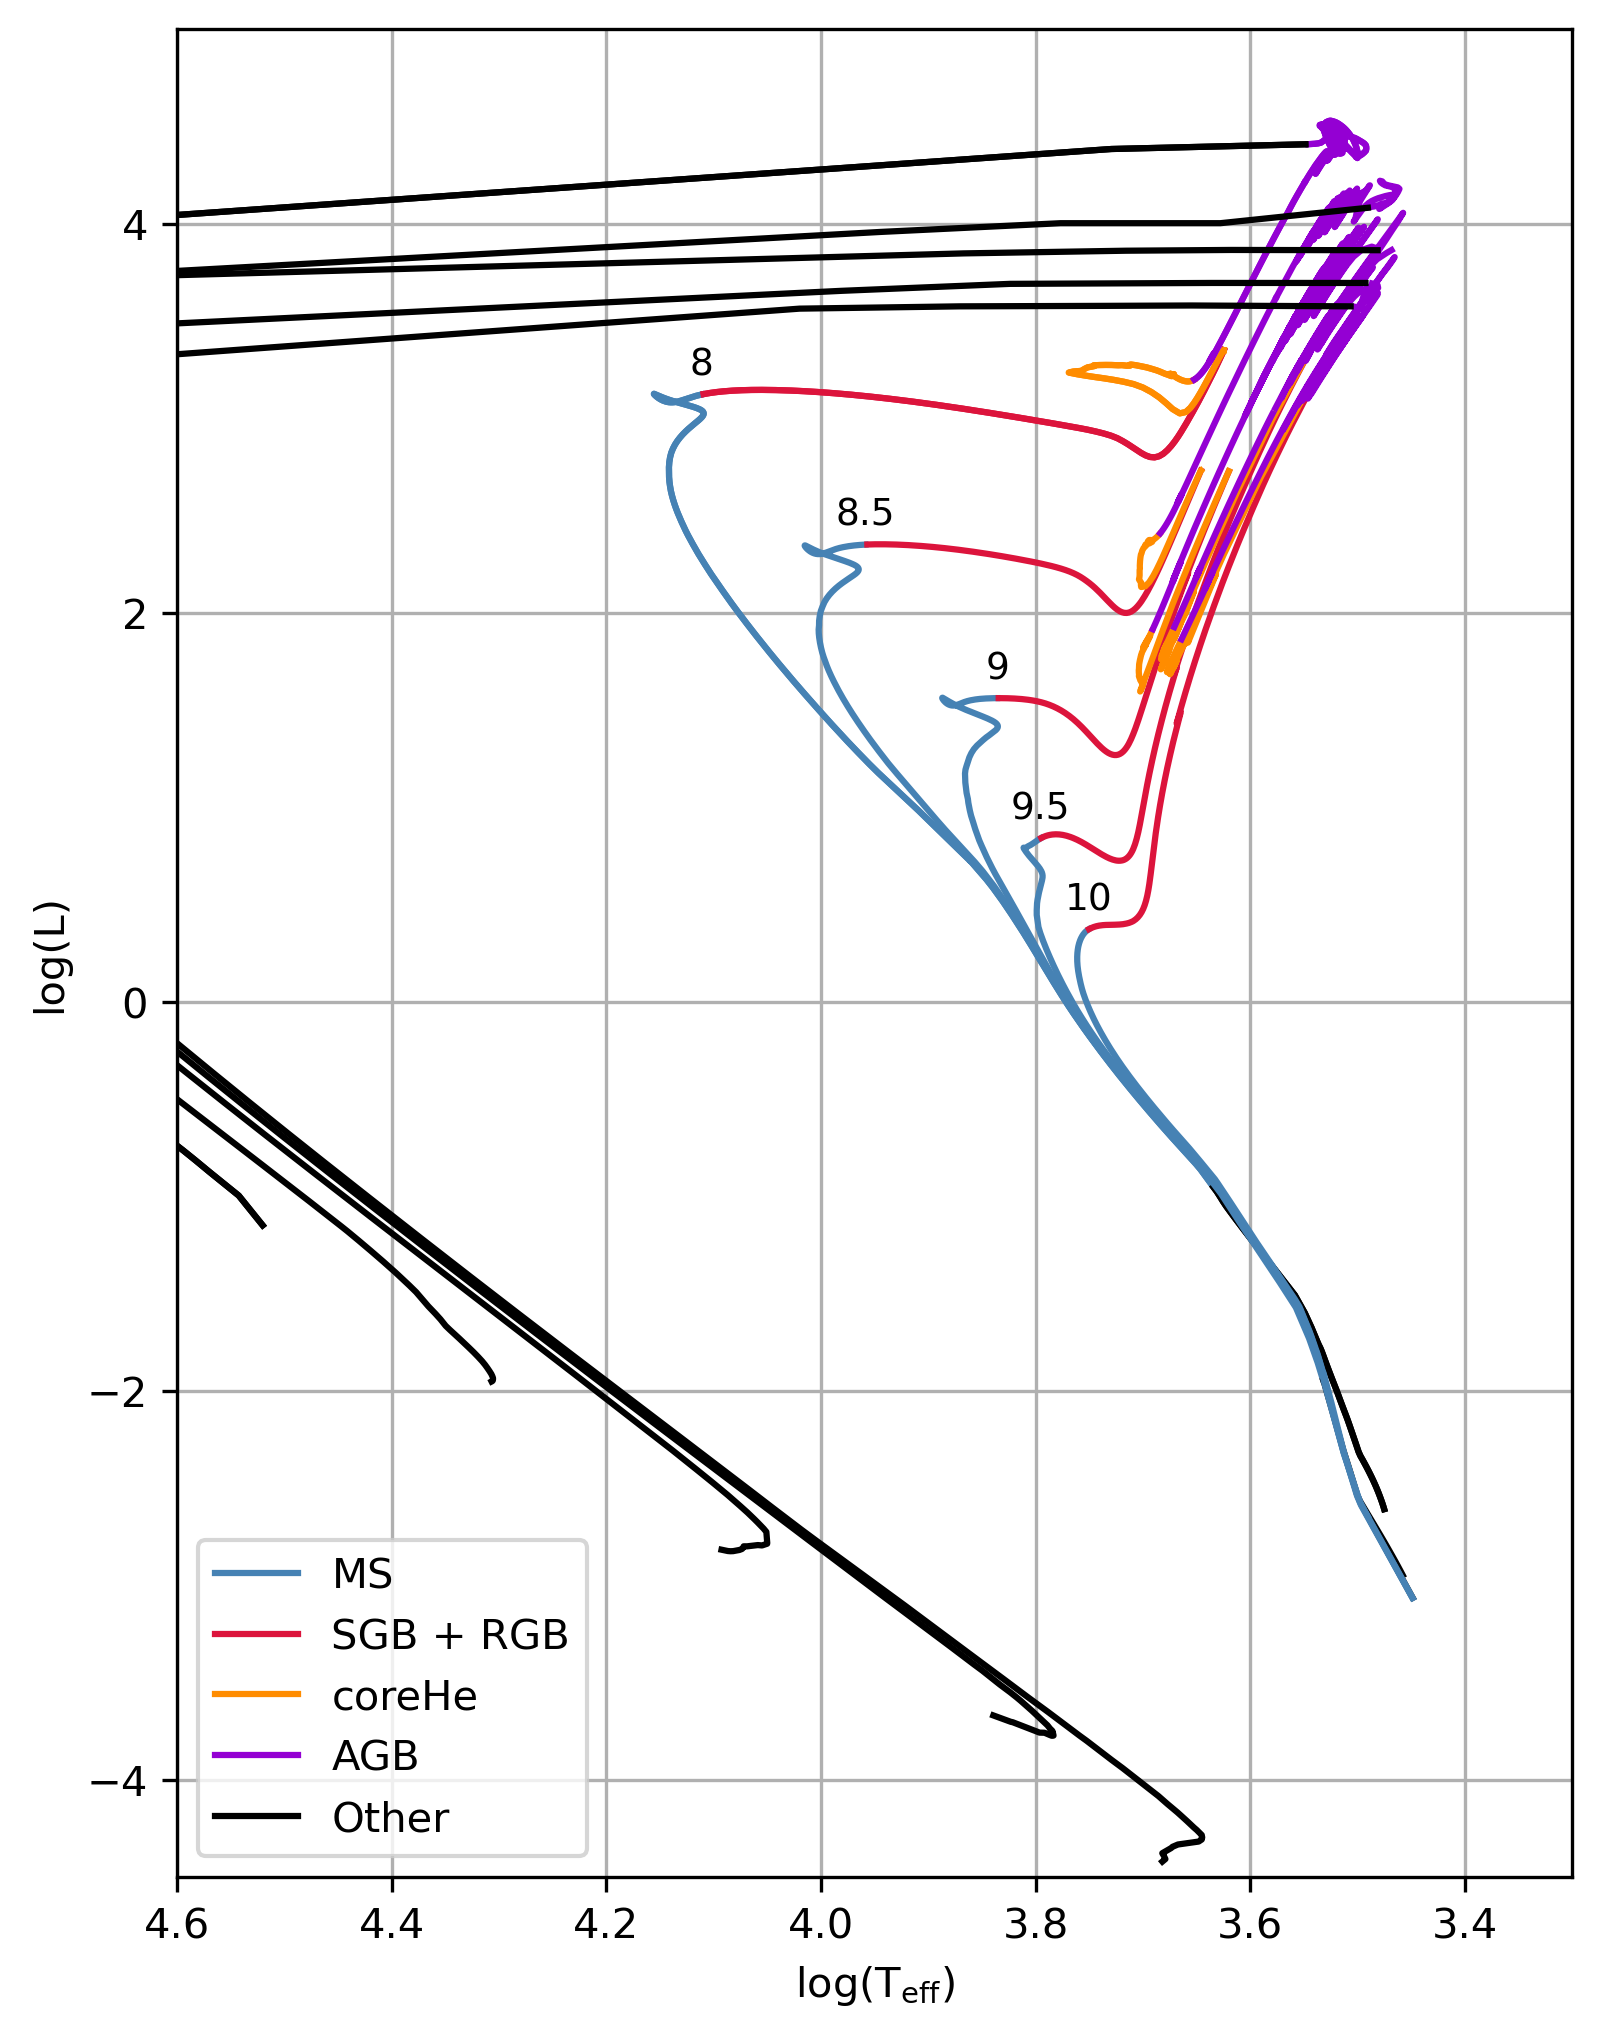

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 8), dpi=300)
for age in (8, 8.5, 9, 9.5, 10):
    age_ind = iso.age_index(age) #returns the index for the desired age
    logTeff = iso.isos[age_ind]['log_Teff']
    logL = iso.isos[age_ind]['log_L']
    phase = iso.isos[age_ind]['phase']

    # base color = black, phase: 0 = MS (green), 2 = SGB + RGB (Red), 3 = coreHe (purple), 4, 5, 6 = AGB (blue)

    # Color mapping by phase
    colors = {
        0: 'steelblue',   # Main Sequence
        2: 'crimson',     # SGB + RGB
        3: 'darkorange',  # Core He burning
        4: 'darkviolet',    # AGB
        5: 'darkviolet'
    }

    labls = {
        0: 'MS',   # Main Sequence
        2: 'SGB + RGB',     # SGB + RGB
        3: 'coreHe',  # Core He burning
        4: 'AGB',    # AGB
        -1: 'Other'
    }

    # Plot each phase separately
    for p in set(phase):
        mask = (phase == p)
        color = colors.get(p, 'black')  # default = black
        labl = labls.get(p, '')
        if age == 8:
            ax.plot(logTeff[mask], logL[mask], color=color, label=labl)
        ax.plot(logTeff[mask], logL[mask], color=color)

    # --- Find MS turnoff (last MS point before phase changes) ---
    ms_mask = (phase == 0)
    ms_indices = np.where(ms_mask)[0]

    if len(ms_indices) > 0:
        turnoff_idx = ms_indices[-1]  # last MS point

        x_to = logTeff[turnoff_idx]
        y_to = logL[turnoff_idx]

        # Add label slightly above
        ax.text(x_to, y_to + 0.1, f'{age}', fontsize=9, ha='center')
    
    ax.set_xlabel(r'log(T$_\text{eff}$)')
    ax.set_ylabel('log(L)')
    ax.axis([4.6, 3.3, -4.5, 5])
    ax.grid(which='both')
    ax.legend()
plt.savefig('2a_isochrones.png')
plt.show()